# 1. Importing all the required libraries: 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# 2. Data Exploration:

In [3]:
df = pd.read_csv("/Users/laxmigupte/Desktop/Ironhack/week5/Mini project 2/King-County-Housing/data/king_ country_ houses_aa.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.shape

(21613, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [7]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

Setting the 'TARGET' column

In [8]:
target = "price"

Detecting missing or Null values

In [9]:
df.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

## 3. Initial Data Cleaning

Checking for Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["id"].duplicated().sum()

np.int64(177)

ANALYSIS:

There are no missing values and no completely duplicated rows.

Some 'id' values are repeated, but this does not necessary that they are wrong. The same house may have been sold more than once.

###  We create a copy of the dataset and remove fully duplicated rows if there are any.

In [13]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

df_clean.shape

(21613, 21)

The 'date' column is converted to datetime format.

Then, we create new time-related variables from it.

In [14]:
df_clean["date"] = pd.to_datetime(df_clean["date"])

df_clean[["date"]].head()

,date
0,2014-10-13
1,2014-12-09
2,2015-02-25
3,2014-12-09
4,2015-02-18


Creating two additional columns derived from the date. 

1st: This helps the model identify if house prices are rising year-over-year. 

2: This is crucial for capturing seasonality. For example, houses might sell for more in the summer than in the winter.

In [15]:
df_clean["sale_year"] = df_clean["date"].dt.year
df_clean["sale_month"] = df_clean["date"].dt.month

df_clean[["date", "sale_year", "sale_month"]].head()

,date,sale_year,sale_month
0,2014-10-13,2014,10
1,2014-12-09,2014,12
2,2015-02-25,2015,2
3,2014-12-09,2014,12
4,2015-02-18,2015,2


We create new features related to the age and renovation status of the house.

In [16]:
df_clean["house_age"] = df_clean["sale_year"] - df_clean["yr_built"]

df_clean["was_renovated"] = np.where(df_clean["yr_renovated"] > 0, 1, 0)

df_clean["years_since_renovation"] = np.where(
    df_clean["yr_renovated"] > 0,
    df_clean["sale_year"] - df_clean["yr_renovated"],
    0
)

df_clean[
    [
        "yr_built",
        "yr_renovated",
        "sale_year",
        "house_age",
        "was_renovated",
        "years_since_renovation"
    ]
].head()

,yr_built,yr_renovated,sale_year,house_age,was_renovated,years_since_renovation
0,1955,0,2014,59,0,0
1,1951,1991,2014,63,1,23
2,1933,0,2015,82,0,0
3,1965,0,2014,49,0,0
4,1987,0,2015,28,0,0


## 4. Explore the Target Variable

We analyze the distribution of house prices

In [17]:
df_clean["price"].describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

Creating a visual to see the distribution of house prices.

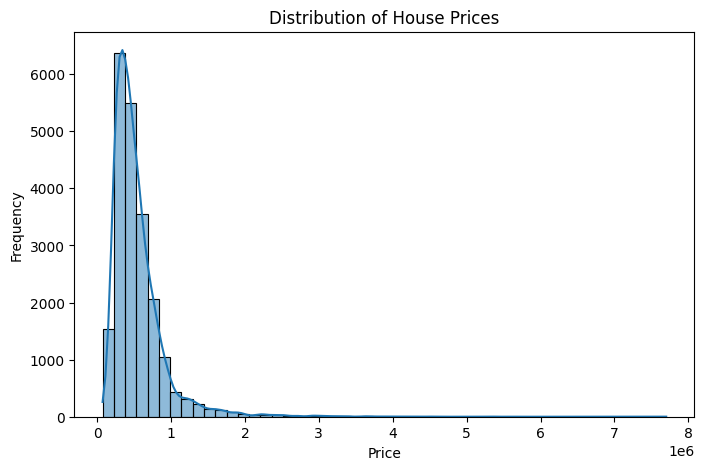

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

ANALYSIS:

The price distribution is right-skewed.

This means that most houses have moderate prices, but there are some very expensive houses.

## 5. Explore Correlations

We calculate the correlations between numerical variables and the target variable.

In [19]:
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])

correlations = numeric_df.corr()["price"].sort_values(ascending=False)

correlations

price                     1.000000
sqft_living               0.702035
grade                     0.667434
sqft_above                0.605567
sqft_living15             0.585379
bathrooms                 0.525138
view                      0.397293
sqft_basement             0.323816
bedrooms                  0.308350
lat                       0.307003
waterfront                0.266369
floors                    0.256794
yr_renovated              0.126434
was_renovated             0.126092
sqft_lot                  0.089661
sqft_lot15                0.082447
years_since_renovation    0.067177
yr_built                  0.054012
condition                 0.036362
long                      0.021626
id                       -0.016762
zipcode                  -0.053203
house_age                -0.053951
Name: price, dtype: float64

In [20]:
correlations.head(10)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
Name: price, dtype: float64

The strongest positive correlations with 'price' are usually related to house size, quality, location, views, and bathrooms.

Creating a visual to see the correlation of the features to the house prices.

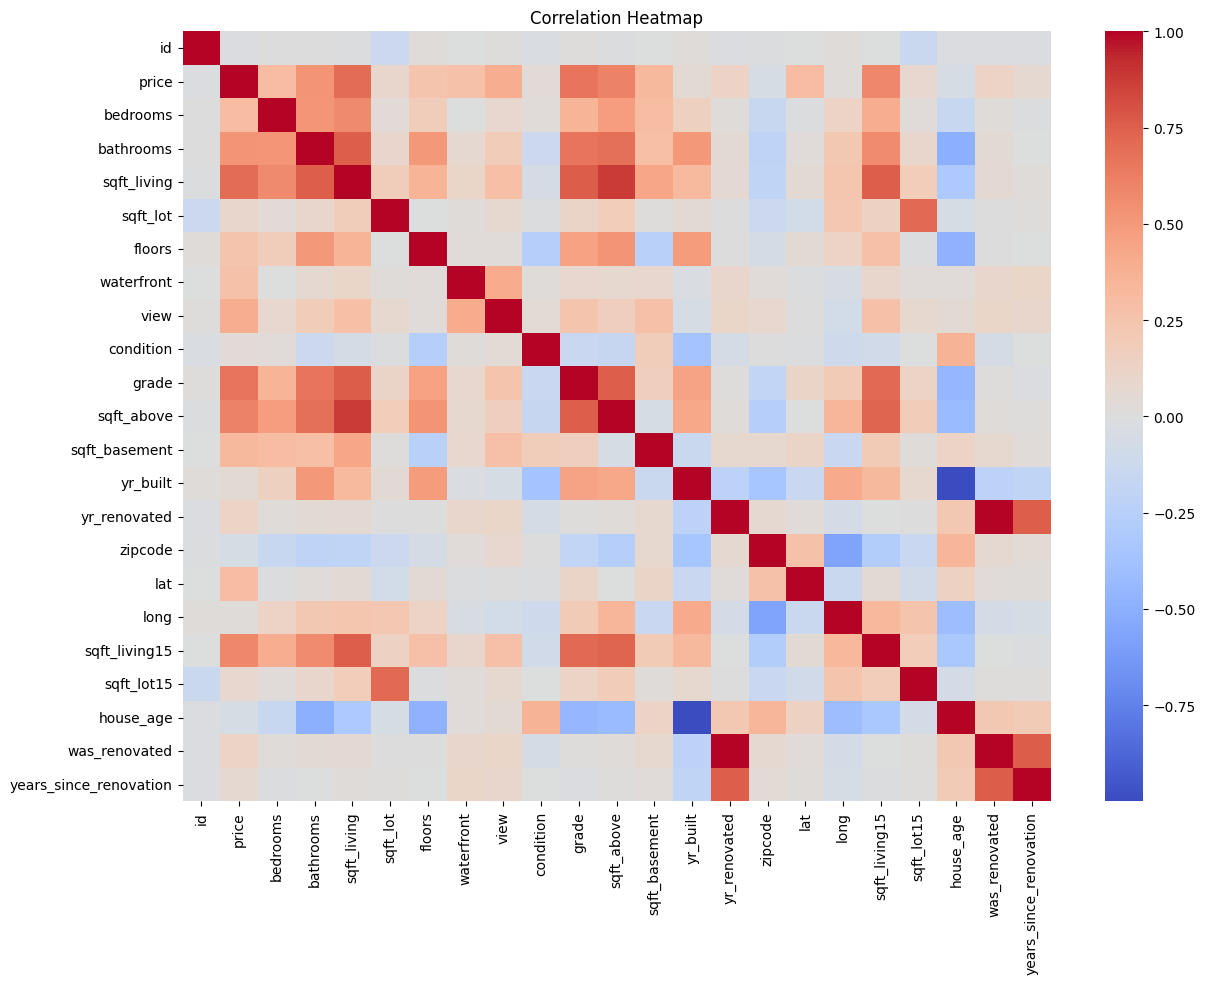

In [21]:
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

Creating a visual to see the numerical correlation of the featires to house prices.

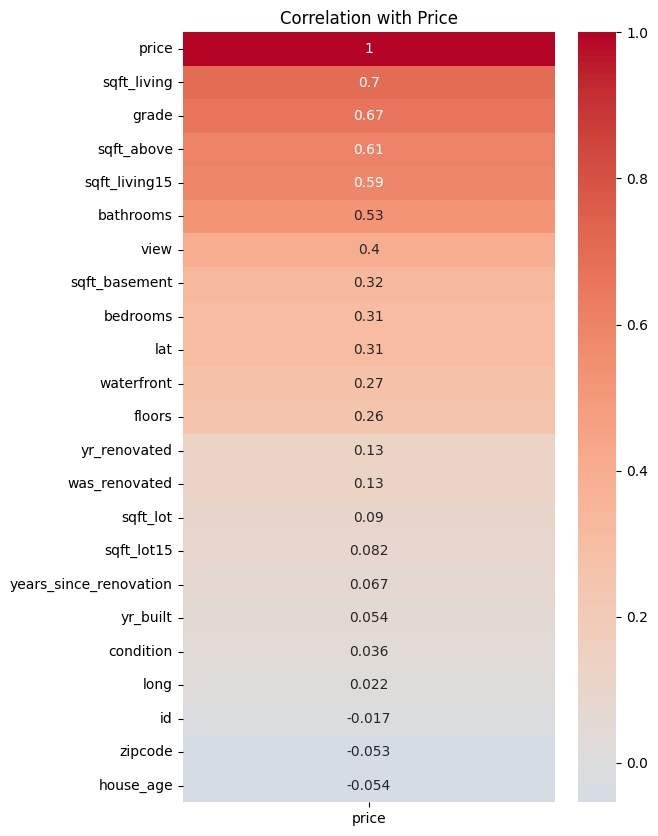

In [22]:
plt.figure(figsize=(6, 10))
sns.heatmap(
    correlations.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation with Price")
plt.show()

## 6. Check Multicollinearity

In [23]:
corr_matrix = numeric_df.corr()

high_corr_pairs = []

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2:
            corr_value = corr_matrix.loc[col1, col2]
            
            if abs(corr_value) > 0.7:
                pair = tuple(sorted([col1, col2]))
                high_corr_pairs.append((pair[0], pair[1], corr_value))

high_corr_pairs = list(set(high_corr_pairs))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["variable_1", "variable_2", "correlation"]
)

high_corr_df.sort_values(by="correlation", ascending=False)

,variable_1,variable_2,correlation
8,was_renovated,yr_renovated,0.999968
5,sqft_above,sqft_living,0.876597
1,grade,sqft_living,0.762704
0,was_renovated,years_since_renovation,0.758219
3,sqft_living,sqft_living15,0.756420
6,grade,sqft_above,0.755923
10,bathrooms,sqft_living,0.754665
9,years_since_renovation,yr_renovated,0.753021
7,sqft_above,sqft_living15,0.731870
11,sqft_lot,sqft_lot15,0.718557


ANALYSIS:

Some variables related to size are strongly correlated with each other.

For example, sqft_living, sqft_above, and sqft_basement are connected because they describe different parts of the house size.

## 7. Explore Outliers

In [24]:
df_clean[["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot"]].describe().T

,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.141767,367127.196483,75000.0,321950.00,450000.00,645000.0,7700000.0
bedrooms,21613.0,3.370842,0.930062,0.0,3.00,3.00,4.0,33.0
bathrooms,21613.0,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,2079.899736,918.440897,290.0,1427.00,1910.00,2550.0,13540.0
sqft_lot,21613.0,15106.967566,41420.511515,520.0,5040.00,7618.00,10688.0,1651359.0


Creating a visual to spot the outliers of our Price

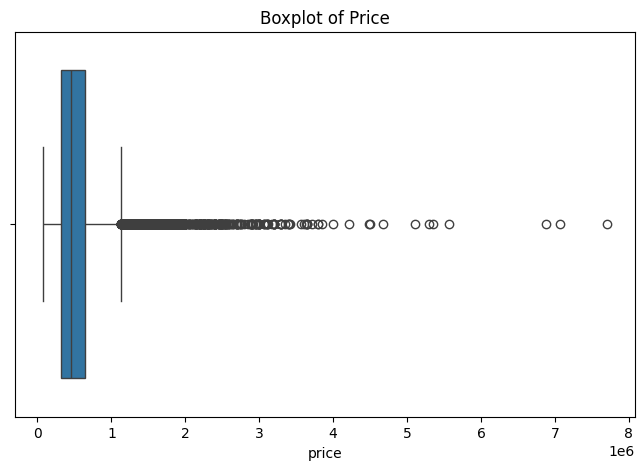

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["price"])
plt.title("Boxplot of Price")
plt.show()

Creating a visual to spot the outliers of the number of bedrooms

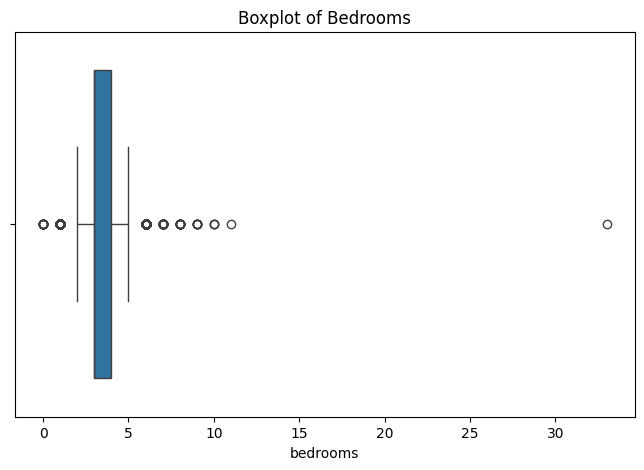

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["bedrooms"])
plt.title("Boxplot of Bedrooms")
plt.show()

Creating a visual to spot the outliers of the number of bathrooms

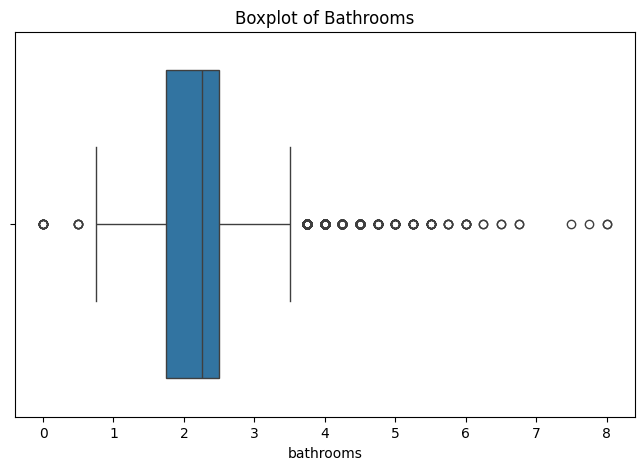

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["bathrooms"])
plt.title("Boxplot of Bathrooms")
plt.show()

### We remove some extreme values (the outliers) to make the model focus on the most common housing market behavior.

In [28]:
df_model = df_clean.copy()

# Remove unrealistic bedroom and bathroom values
df_model = df_model[df_model["bedrooms"].between(1, 10)]
df_model = df_model[df_model["bathrooms"].between(1, 6)]

# Remove the most extreme 1% of prices on both sides
price_low = df_model["price"].quantile(0.01)
price_high = df_model["price"].quantile(0.99)

df_model = df_model[
    (df_model["price"] >= price_low) &
    (df_model["price"] <= price_high)
]

df_model.shape

(21087, 26)

## 8. Feature Engineering

Additional variables for simplying multiple columns

In [30]:
df_model["has_basement"] = np.where(df_model["sqft_basement"] > 0, 1, 0)

df_model["basement_ratio"] = df_model["sqft_basement"] / df_model["sqft_living"]

df_model["living_lot_ratio"] = df_model["sqft_living"] / df_model["sqft_lot"]

df_model["total_rooms"] = df_model["bedrooms"] + df_model["bathrooms"]

df_model.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_lot15,sale_year,sale_month,house_age,was_renovated,years_since_renovation,has_basement,basement_ratio,living_lot_ratio,total_rooms
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,5650,2014,10,59,0,0,0,0.000000,0.208850,4.00
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7639,2014,12,63,1,23,1,0.155642,0.354874,5.25
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,8062,2015,2,82,0,0,0,0.000000,0.077000,3.00
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,5000,2014,12,49,0,0,1,0.464286,0.392000,7.00
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,7503,2015,2,28,0,0,0,0.000000,0.207921,5.00


## 9. Split the Dataset into X and y

X contains the features.

y contains the target variable.

In [31]:
y = df_model["price"]

X = df_model.drop(columns=[
    "price",
    "id",
    "date",
    "sqft_above",
    "sqft_basement"
])

### A zipcode is not a real numerical quantity, so we convert it to categorical range.

In [32]:
X["zipcode"] = X["zipcode"].astype(str)

In [33]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,yr_built,...,sqft_lot15,sale_year,sale_month,house_age,was_renovated,years_since_renovation,has_basement,basement_ratio,living_lot_ratio,total_rooms
0,3,1.00,1180,5650,1.0,0,0,3,7,1955,...,5650,2014,10,59,0,0,0,0.000000,0.208850,4.00
1,3,2.25,2570,7242,2.0,0,0,3,7,1951,...,7639,2014,12,63,1,23,1,0.155642,0.354874,5.25
2,2,1.00,770,10000,1.0,0,0,3,6,1933,...,8062,2015,2,82,0,0,0,0.000000,0.077000,3.00
3,4,3.00,1960,5000,1.0,0,0,5,7,1965,...,5000,2014,12,49,0,0,1,0.464286,0.392000,7.00
4,3,2.00,1680,8080,1.0,0,0,3,8,1987,...,7503,2015,2,28,0,0,0,0.000000,0.207921,5.00


In [34]:
y.head()

0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

## 10. Separate Numerical and Categorical Features

In [35]:
categorical_features = ["zipcode"]

numeric_features = []

for column in X.columns:
    if column not in categorical_features:
        numeric_features.append(column)

print("Numerical features:")
print(numeric_features)

print("Categorical features:")
print(categorical_features)

Numerical features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'house_age', 'was_renovated', 'years_since_renovation', 'has_basement', 'basement_ratio', 'living_lot_ratio', 'total_rooms']
Categorical features:
['zipcode']


## 11. Train-Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16869, 25)
X_test shape: (4218, 25)
y_train shape: (16869,)
y_test shape: (4218,)


## 12. Preprocessing

We prepare numerical and categorical variables differently.

Numerical variables:
- missing values are filled with the median;
- values are standardized.

Categorical variables:
- missing values are filled with the most frequent value;
- categories are converted into numerical columns using One Hot Encoding.

In [37]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 13. Function to Evaluate Models

In [38]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    results = {
        "model": model_name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }
    
    return results

## 14. Train Baseline Models

We start with simple baseline models:
- Linear Regression
- KNN Regressor

In [39]:
linear_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

knn_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

baseline_models = {
    "Linear Regression": linear_model,
    "KNN Regressor": knn_model
}

In [40]:
baseline_results = []

for model_name, model in baseline_models.items():
    result = evaluate_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,model,R2,MAE,RMSE
0,Linear Regression,0.842161,78278.427677,112435.719722
1,KNN Regressor,0.780189,83059.909009,132684.815069


ANALYSIS:

The baseline models give us a first reference point.

Later, we will compare more advanced models against these results.

## 15. Train Improved Models

Now we try more advanced models:
- Ridge Regression
- Random Forest
- Gradient Boosting

In [41]:
ridge_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", Ridge(alpha=10))
])

random_forest_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])

gradient_boosting_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

improved_models = {
    "Ridge Regression": ridge_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

In [42]:
improved_results = []

for model_name, model in improved_models.items():
    result = evaluate_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    improved_results.append(result)

improved_results_df = pd.DataFrame(improved_results)

improved_results_df

,model,R2,MAE,RMSE
0,Ridge Regression,0.839621,78831.434711,113336.703304
1,Random Forest,0.863719,63874.189236,104475.598938
2,Gradient Boosting,0.858973,70575.495504,106279.173286


## 16. Compare All Models

In [43]:
all_results_df = pd.concat(
    [baseline_results_df, improved_results_df],
    ignore_index=True
)

all_results_df = all_results_df.sort_values(by="MAE")

all_results_df

,model,R2,MAE,RMSE
3,Random Forest,0.863719,63874.189236,104475.598938
4,Gradient Boosting,0.858973,70575.495504,106279.173286
0,Linear Regression,0.842161,78278.427677,112435.719722
2,Ridge Regression,0.839621,78831.434711,113336.703304
1,KNN Regressor,0.780189,83059.909009,132684.815069


Creating a visual of model comparison by MAE

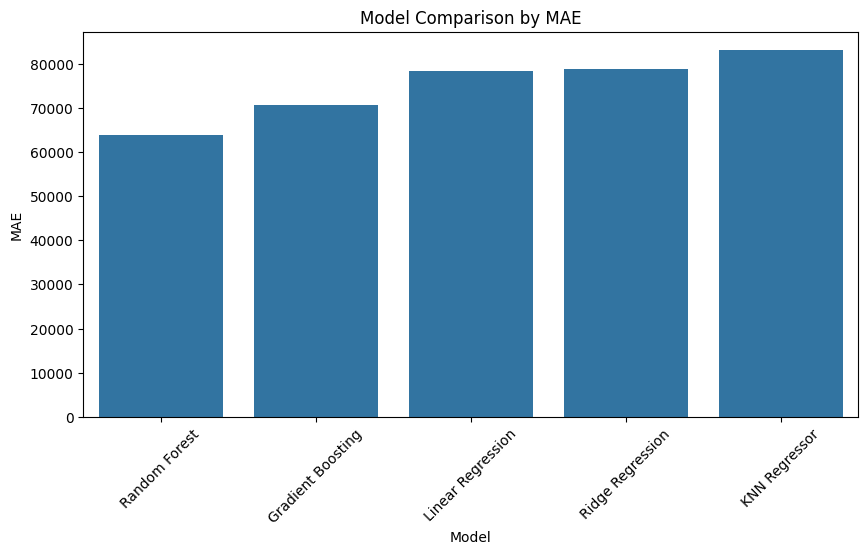

In [44]:
plt.figure(figsize=(10, 5))
sns.barplot(data=all_results_df, x="model", y="MAE")
plt.xticks(rotation=45)
plt.title("Model Comparison by MAE")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.show()

Creating a visual of model comparison by R2

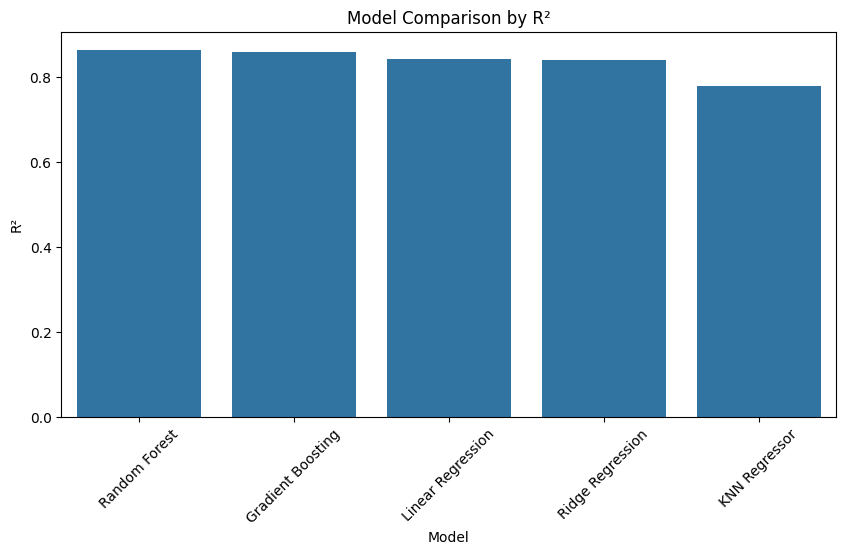

In [45]:
plt.figure(figsize=(10, 5))
sns.barplot(data=all_results_df, x="model", y="R2")
plt.xticks(rotation=45)
plt.title("Model Comparison by R²")
plt.ylabel("R²")
plt.xlabel("Model")
plt.show()

OBSEVATIONS:

The best model should have:
- the lowest MAE
- the lowest RMSE
- the highest R²

## 17. Hyperparameter Tuning

We try to improve the Random Forest model using RandomizedSearchCV.

In [46]:
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_distributions = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 0.7, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [47]:
random_search.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 1,
 'model__max_features': 0.7,
 'model__max_depth': 20}

In [48]:
best_rf_model = random_search.best_estimator_

tuned_rf_result = evaluate_model(
    "Tuned Random Forest",
    best_rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

tuned_rf_result

{'model': 'Tuned Random Forest',
 'R2': 0.8666292466379044,
 'MAE': 63188.08443463279,
 'RMSE': np.float64(103353.99300605066)}

In [44]:
all_results_df = pd.concat(
    [
        all_results_df,
        pd.DataFrame([tuned_rf_result])
    ],
    ignore_index=True
)

all_results_df = all_results_df.sort_values(by="MAE")

all_results_df

,model,R2,MAE,RMSE
5,Tuned Random Forest,0.866629,63188.084435,103353.993006
0,Random Forest,0.863719,63874.189236,104475.598938
1,Gradient Boosting,0.858973,70575.495504,106279.173286
2,Linear Regression,0.842161,78278.427677,112435.719722
3,Ridge Regression,0.839621,78831.434711,113336.703304
4,KNN Regressor,0.780189,83059.909009,132684.815069


## 18. Select the Best Model

In [45]:
best_model_row = all_results_df.sort_values(by="MAE").iloc[0]

best_model_row

model    Tuned Random Forest
R2                  0.866629
MAE             63188.084435
RMSE           103353.993006
Name: 5, dtype: object

In [46]:
best_model_name = best_model_row["model"]

print("The best model according to MAE is:", best_model_name)

The best model according to MAE is: Tuned Random Forest


## 19. Train the Final Model

In [47]:
final_model = best_rf_model

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

final_r2 = r2_score(y_test, final_predictions)
final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))

print("Final R²:", final_r2)
print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)

Final R²: 0.8666292466379044
Final MAE: 63188.084434632794
Final RMSE: 103353.99300605066


## 20. Compare Real Prices and Predicted Prices

In [48]:
comparison_df = pd.DataFrame({
    "real_price": y_test,
    "predicted_price": final_predictions
})

comparison_df["error"] = comparison_df["real_price"] - comparison_df["predicted_price"]
comparison_df["absolute_error"] = abs(comparison_df["error"])

comparison_df.head(10)

,real_price,predicted_price,error,absolute_error
15820,784000.0,917297.040533,-133297.040533,133297.040533
5210,655000.0,682298.221005,-27298.221005,27298.221005
5684,395300.0,422830.375310,-27530.375310,27530.375310
6678,830000.0,848283.343875,-18283.343875,18283.343875
10841,265000.0,230300.214121,34699.785879,34699.785879
7651,510000.0,610326.558645,-100326.558645,100326.558645
14660,802500.0,775706.096879,26793.903121,26793.903121
3902,270000.0,360386.692398,-90386.692398,90386.692398
14150,290000.0,330202.335708,-40202.335708,40202.335708
10083,650000.0,563535.771348,86464.228652,86464.228652


Creating a visual of model comparison between Real prices & Predicted prices

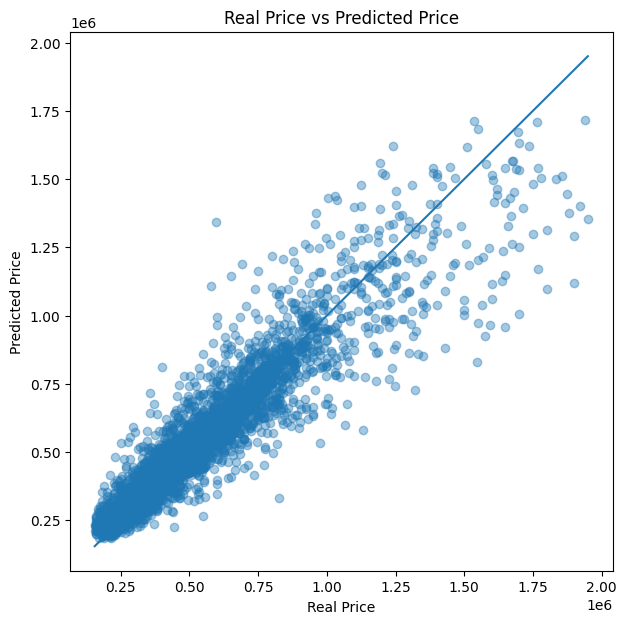

In [49]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, final_predictions, alpha=0.4)
plt.xlabel("Real Price")
plt.ylabel("Predicted Price")
plt.title("Real Price vs Predicted Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

## 21. Analyze Prediction Errors

Creating a visual of distribution of Prediction errors

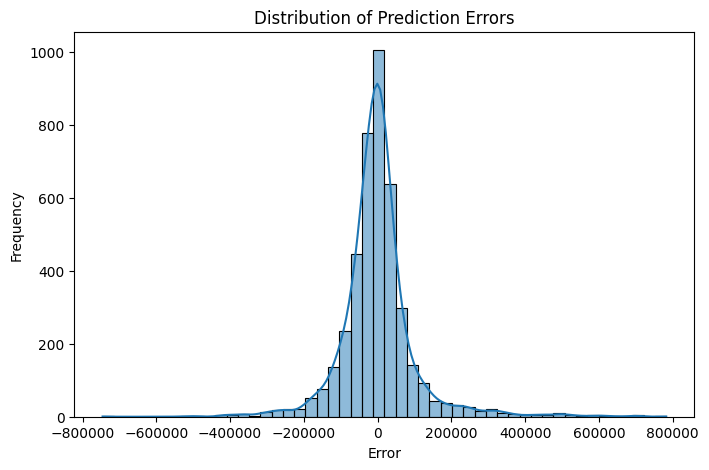

In [50]:
plt.figure(figsize=(8, 5))
sns.histplot(comparison_df["error"], bins=50, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [51]:
comparison_df["absolute_error"].describe()

count      4218.000000
mean      63188.084435
std       81797.922522
min          27.232500
25%       16005.609976
50%       36733.832952
75%       76455.640070
max      782345.233288
Name: absolute_error, dtype: float64

## 22. Feature Importance

Since the final model is a Random Forest model, we can extract feature importance values.

In [52]:
preprocessor_fitted = final_model.named_steps["preprocessing"]
model_fitted = final_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()

clean_feature_names = []

for name in feature_names:
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    clean_feature_names.append(name)

importances = model_fitted.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": clean_feature_names,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(20)

,feature,importance
8,grade,0.321405
11,lat,0.221776
2,sqft_living,0.190784
13,sqft_living15,0.054857
12,long,0.049639
17,house_age,0.023222
9,yr_built,0.019415
6,view,0.012183
3,sqft_lot,0.011896
14,sqft_lot15,0.011432


Creating a visual of top 20 important features

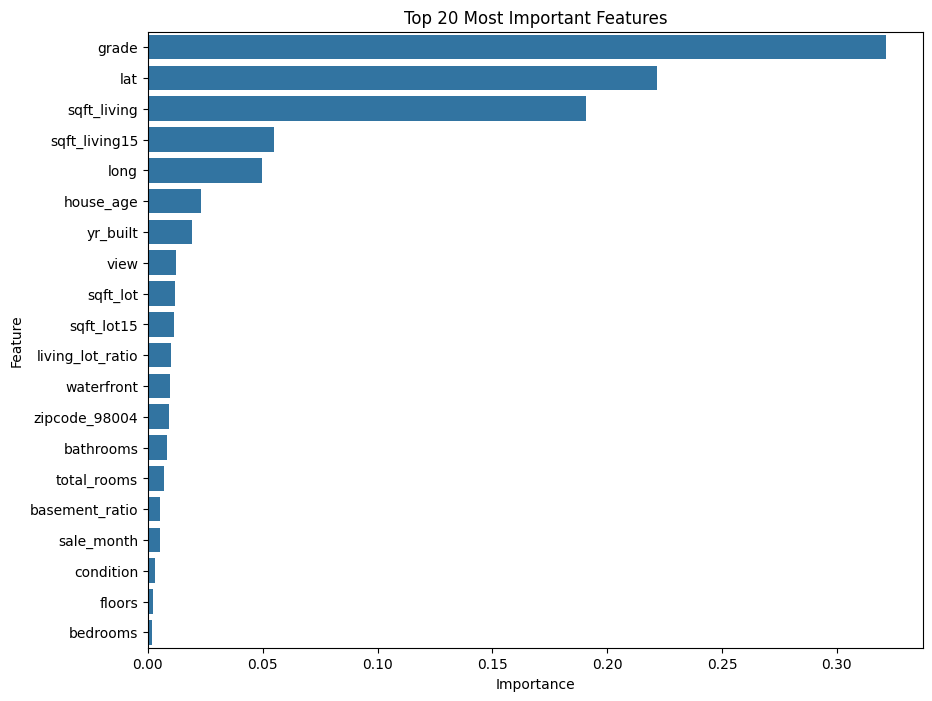

In [53]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df.head(20),
    x="importance",
    y="feature"
)
plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Final Conclusions

In this project, we built several regression models to predict house prices.

The dataset was loaded, explored, cleaned, and prepared for machine learning.

The target variable was 'price'.

We checked missing values, duplicates, correlations, multicollinearity, and outliers.

We also created new features such as 'house_age', 'was_renovated', 'has_basement', 'basement_ratio', 'living_lot_ratio', and 'total_rooms'.

The categorical variable 'zipcod' wasencoded using One Hot Encoding.

Several models were trained and evaluated:
- Linear Regression;
- KNN Regressor;
- Ridge Regression;
- Random Forest;
- Gradient Boosting;
- Tuned Random Forest.

The best model was selected using mainly MAE, because MAE shows the average prediction error in dollars.

Ensemble models such as Random Forest and Gradient Boosting usually performed better than simple baseline models because they can capture more complex relationships.

The most influential features were mainly related to house size, quality, and location.

### THANK-YOU!